In [1]:
import torch
import torch.nn as nn
import numpy as np
import darcySolver as ds
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from tqdm import tqdm
rng=np.random.default_rng(seed=101)
import torch.optim as optim
import importlib

import torchvision.transforms as transforms
from torchvision import datasets as datasets
import dataloaders
importlib.reload(dataloaders)
from dataloaders import get_darcy_dataloader_transformers
from os import mkdir

from scipy.ndimage import zoom
import time
import cProfile
from scipy.interpolate import griddata
import arviz as az

from scipy.interpolate import RectBivariateSpline
from statsmodels.graphics.tsaplots import plot_acf
from mpl_toolkits.axes_grid1 import make_axes_locatable



In [2]:
import sys, site
print("PYTHON:", sys.executable)
print("VERSION:", sys.version)
print("SITE:", site.getsitepackages() if hasattr(site, "getsitepackages") else "n/a")

PYTHON: /home/ziqih2/anaconda3/envs/fenicsx/bin/python
VERSION: 3.10.13 | packaged by conda-forge | (main, Dec 23 2023, 15:36:39) [GCC 12.3.0]
SITE: ['/home/ziqih2/anaconda3/envs/fenicsx/lib/python3.10/site-packages']


In [3]:
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

2.4.1+cu118
CUDA available: True
GPU name: NVIDIA GeForce RTX 4090


In [4]:
def plot_image(image_reshaped):
    im = plt.imshow(image_reshaped, cmap="gray")
    cbar = plt.colorbar(im)
    plt.show()

In [5]:
# def plot_darcy_select_point(points, A_choose):
#     plt.figure(figsize=(5, 5))
#     sc = plt.scatter(A_choose[:, 0], A_choose[:, 1], c=points, cmap='viridis', s=30)
#     # plt.colorbar(sc, label='Function Value')
#     plt.xlim(0, 1)
#     plt.ylim(0, 1)
#     plt.gca().set_aspect('equal')
#     # plt.title("Function values at 60 selected points")
#     # plt.xlabel("x")
#     # plt.ylabel("y")
#     divider = make_axes_locatable(ax)
#     cax = divider.append_axes("right", size="4%", pad=0.05)
#     cbar = plt.colorbar(sc)
#     # cbar.set_label("Function Value")
#     plt.grid(True)
#     plt.show()
def plot_darcy_select_point(points, A_choose):
    fig, ax = plt.subplots(figsize=(5, 5))
    sc = ax.scatter(
        A_choose[:, 0],
        A_choose[:, 1],
        c=points,
        cmap='viridis',
        s=30
    )

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.2)
    cbar = fig.colorbar(sc, cax=cax)
    # cbar.set_label("Function Value")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.grid(True)
    plt.show()

In [6]:
def plot_darcy_contour(testing_image, grid_num):
    testing_image = testing_image.reshape(grid_num, grid_num)

    plt.imshow(
        testing_image,
        cmap="viridis",
        origin="lower",
        extent=[0, 1, 0, 1],
        vmin=0,  # optionally fix color scale
    )
    plt.colorbar(label="Pressure")
    plt.xlabel("x")
    plt.ylabel("y")
    # plt.title("True Solution u (imshow)")
    plt.show()

In [7]:
# Hyperparameters for WGANgp
latent_size = 64
batch_size = 100
image_side = 16
y_side = 28
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = latent_size 

In [8]:
class Generator(nn.Module):
    def __init__(self, input_dim=latent_size, output_dim=784):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, output_dim),
            nn.Tanh()  # Normalize output between -1 and 1
        )

    def forward(self, z):
        img = self.model(z)
        return img  # Output shape (batch_size, 784)

class Critic(nn.Module):
    def __init__(self, input_dim=latent_size):
        super(Critic, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)  # Output a single critic score
        )

    def forward(self, img):
        validity = self.model(img)
        return validity

In [9]:
# Initialize models
G = Generator(input_dim=latent_dim, output_dim=784).cuda()
D = Critic(input_dim=latent_size).cuda()
G.load_state_dict(torch.load('./'+str(latent_size)+'/G_WGANgp.pth'))
G.eval()


Generator(
  (model): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

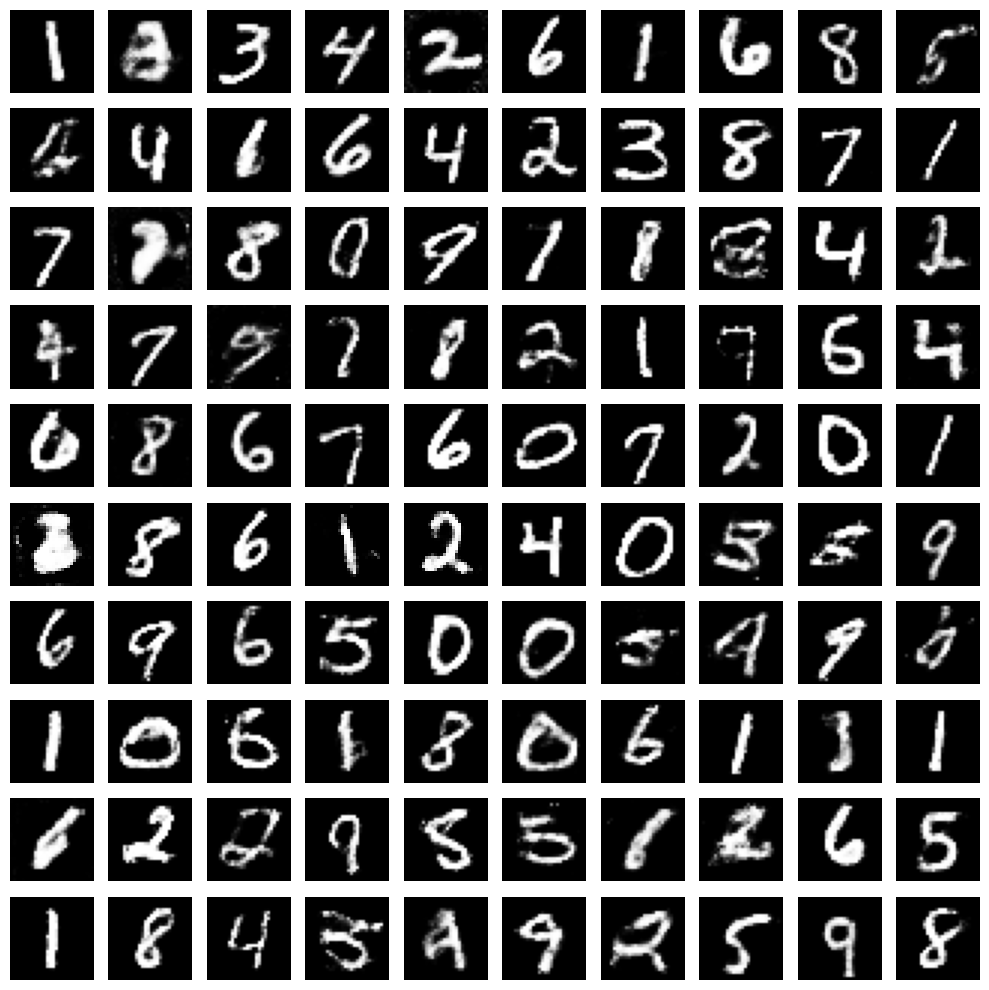

In [10]:
# Check the generator for generating MNIST images
z = torch.randn(batch_size, latent_size).to(device)
fake_images = G(z)
fake_images = fake_images.reshape(fake_images.size(0), 1, 28, 28)
fake_images = fake_images.cpu().data
fig, axes = plt.subplots(10, 10, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(fake_images[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [11]:
# Initialize grid for Darcyflow Solver's Preliminary fields
x_grid=np.linspace(0,1,28)
y_grid=np.linspace(0,1,28)
X,Y=np.meshgrid(x_grid,y_grid)

In [12]:
# Darcysolver
def constant_rhs(x):
    return x[0]*0+1

In [13]:
def make_datapoint(
        permeability_xgrid,
        permeability_ygrid,
        permeability_field,
        num_eval=100,
        f_rhs=constant_rhs
        ):

    interpolated_permeability_field=RectBivariateSpline(
        permeability_xgrid,
        permeability_ygrid,
        permeability_field,
        kx=2,
        ky=2
        )

    permeability_function=lambda x:interpolated_permeability_field(x[0],x[1],grid=False)

    num_cells=100
    darcy=ds.DarcySolver(num_x_cells=num_cells,num_y_cells=num_cells)


    sol=darcy.solve(
        permeability=permeability_function,
        f_rhs=f_rhs
        )
    
    x_obs=np.linspace(0,1,num_eval)
    y_obs=np.linspace(0,1,num_eval)
    Xobs,Yobs=np.meshgrid(x_obs,y_obs)
    sol_observed=sol(Xobs,Yobs,grid=False)
    return sol_observed

In [14]:
def Darcy_sol(unresized_images,xgrid, ygrid, grid_size):
    zoom_factor = grid_size / 28
    resized_images = np.array([zoom(img, zoom_factor, order=3) for img in unresized_images])
    params="""
    n=100000
    num_kernel_points=40
    kernel = matern_three_half(0.5)
    eval_points = 100
    """
    
    permeability_fields = resized_images
    observations=[
        make_datapoint(
        xgrid,
        ygrid,
        field,
        num_eval=grid_size
        ) for field in permeability_fields 
    ]

    X_data_observed=np.array(observations)
    return X_data_observed

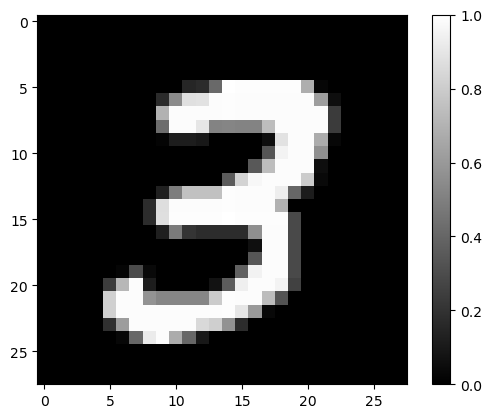

In [15]:
mnist = datasets.MNIST(root='./data', train=True, download=True,
                       transform=transforms.ToTensor())

# Get a single image and label
img, label = mnist[7]

# Display the image
plot_image(img.squeeze())


1.0


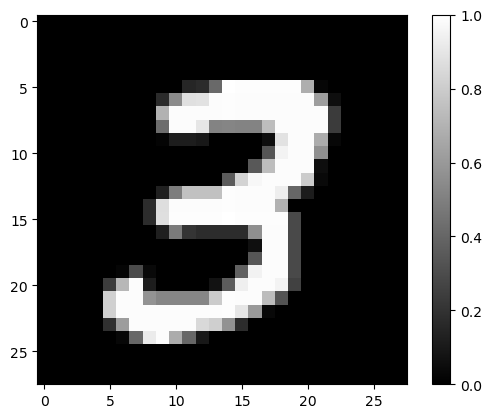

Min: 0.0
Max: 1.0
Total time taken for G: 0.00002 seconds
Total time taken for D: 0.30497 seconds


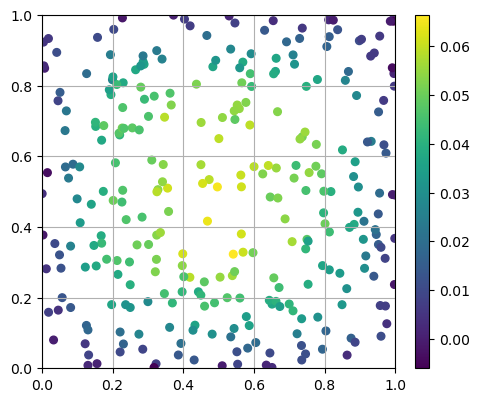

tensor(0.0037, device='cuda:0')


In [16]:
# Check an example MNIST images go through DarcySolver and random picking map A
num_points = 300
A = np.random.rand(num_points, 2)

G_start_time = time.time()
Gx_d = img
G_end_time = time.time()
xgrid=np.linspace(0,1,image_side)
ygrid=np.linspace(0,1,image_side)
xgrid_y = np.linspace(0,1,y_side)
ygrid_y = np.linspace(0,1,y_side)
Gx_d = Gx_d.cpu().detach().numpy()
Gx_d = Gx_d.reshape(-1, 28, 28)
G_testing_image = Gx_d.reshape(28, 28)
print(np.max(G_testing_image))
plot_image(G_testing_image)
print("Min:", np.min(Gx_d))
print("Max:", np.max(Gx_d))
Gx_d = np.exp(Gx_d)
# plot_image(Gx_d.reshape(28, 28))
print(f"Total time taken for G: {G_end_time - G_start_time:.5f} seconds")

D_start_time = time.time()
DGx_d = Darcy_sol(Gx_d,xgrid_y, ygrid_y, 28)
DGx_d = DGx_d.reshape(y_side,y_side)

D_end_time = time.time()
print(f"Total time taken for D: {D_end_time - D_start_time:.5f} seconds")
# plot_darcy_contour(DGx_d, y_side)
interp = RectBivariateSpline(xgrid_y, ygrid_y, DGx_d)
y = np.array([interp(x, y)[0][0] for x, y in zip(A[:, 0], A[:, 1])])

y = torch.from_numpy(y).to(device)
C = np.eye(latent_dim)
C = torch.tensor(torch.from_numpy(C), dtype=torch.float).to(device)
C_ch = torch.linalg.cholesky(C).to(device)
sigma = 0.2*torch.std(y) 
sigma = torch.tensor(sigma, dtype=torch.float).to(device)
y = y + (sigma*torch.randn(y.shape).to(device))
y_test = y.cpu().detach().numpy()
plot_darcy_select_point(y_test,A)
print(sigma)

In [17]:
print("Min:", np.min(Gx_d))
print("Max:", np.max(Gx_d))

Min: 1.0
Max: 2.718282


In [18]:
# Loading MCMC results and corresponding A, G(x_d), beta and sample_Phi as trace plot
# latent_dim = 300
# folder = './MCMC_sample/6_3_01STD_1m/'
folder = './MCMC_sample/6_18_02STD_250k/'
samples_MALA = torch.load(folder+'MCMC_sample.pt')
A = torch.load(folder+'A.pt')
Gx_d = torch.load(folder+'Gx_d.pt')
beta = torch.load(folder+'beta.pt')
sample_Phi = torch.load(folder+'sample_Phi.pt')

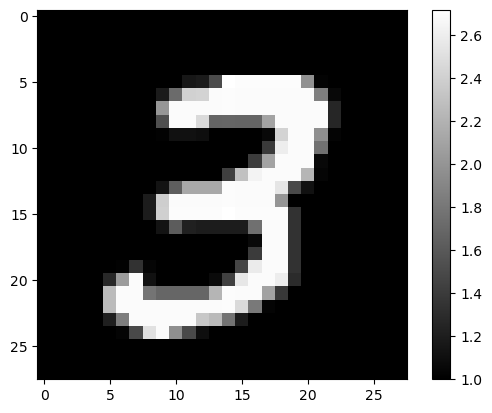

In [19]:
# Viewing y in MNIST image space
testing_true = Gx_d
testing_true = testing_true.reshape(28,28)
plot_image(testing_true)

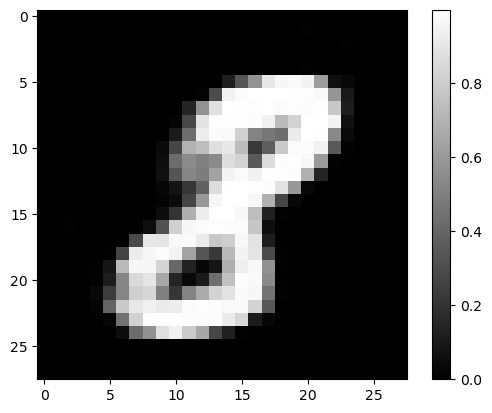

In [20]:
# View the mean of MCMC samples in MNIST space
num_effect = samples_MALA.shape[0]
testing_samples = samples_MALA[0:num_effect]
testing_samples = testing_samples.mean(dim=0).to(device)
testing_samples = testing_samples.reshape(1,latent_size)
testing_samples = G(testing_samples).cpu().detach()
testing_samples = ((testing_samples+1)/2).reshape(28,28)
plot_image(testing_samples)

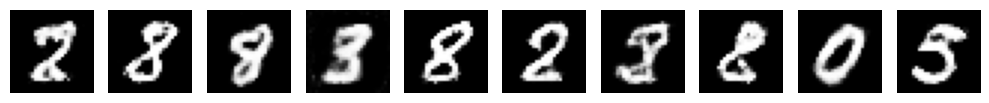

In [21]:
# View 10 samples from MCMC samples
testing_image =samples_MALA[0:200000:20000,:,:].reshape(10,latent_size).to(device)
testing_image = G(testing_image).cpu().detach()
testing_image = testing_image.reshape(10,28,28)
fig, axes = plt.subplots(1, 10, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(testing_image[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

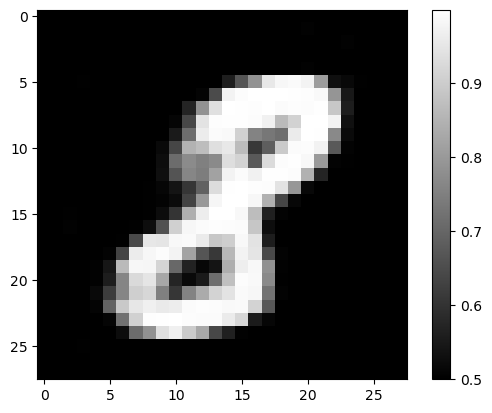

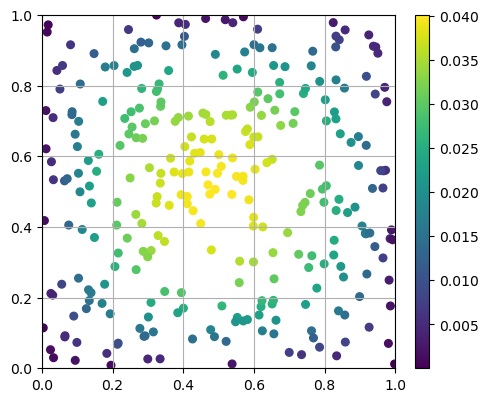

In [22]:
# choosing 1 samples to testing it into DarctSolver
testing_image =samples_MALA[700].reshape(1,latent_size).to(device)
testing_image = G(testing_image).cpu().detach()
testing_image = testing_samples
testing_image = (testing_image+1)/2
G_testing_image = testing_image.reshape(28, 28).tolist()
testing_image = testing_image.reshape(-1, 28, 28).tolist()
plot_image(G_testing_image)
testing_image = np.exp(testing_image)
testing_image = Darcy_sol(testing_image,xgrid, ygrid,image_side)
testing_image = testing_image.reshape(image_side,image_side)
test_interp = RectBivariateSpline(xgrid, ygrid, testing_image)
test_choose = np.array([test_interp(x, y)[0][0] for x, y in zip(A[:, 0], A[:, 1])])
plot_darcy_select_point(test_choose,A)


In [23]:
# fig,ax = plt.subplots()
# index = list(range(num_effect))
# ax.plot(index, samples_MALA[:,10])
# plt.savefig('OT Dimension-2 samples.jpg')
# plt.show()

In [24]:
# plt.plot(samples_MALA[:,1], samples_MALA[:,2])
# plt.show()

In [25]:
# plt.hist2d(samples_MALA[:,1,0], samples_MALA[:,5,0],bins=100)
# plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

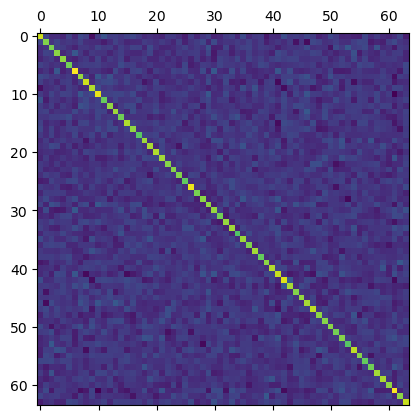

In [26]:
# checking standard deviation for each dimension in latent space 
U = samples_MALA.reshape(num_effect, latent_size).numpy()
U = U.T
mean = np.mean(U,axis=1)
sample_std = np.std(U, axis=1)
covariance = np.cov(U)
std = np.std(U)
covariance.shape
plt.matshow(covariance)
plt.show

0.97768676


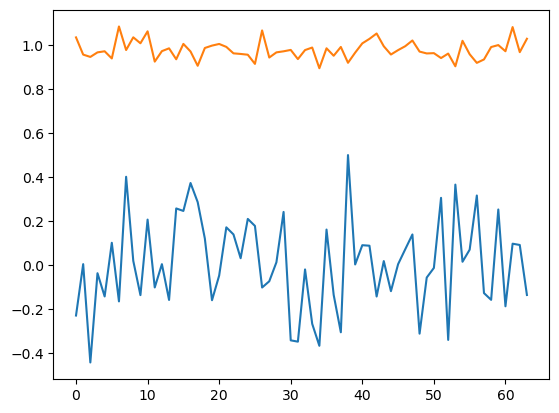

In [27]:
#compare mean and standard deviation for each dimension in latent space
plt.plot(mean)
plt.show

plt.plot(sample_std)
plt.show
print(np.mean(sample_std))

<function matplotlib.pyplot.show(close=None, block=None)>

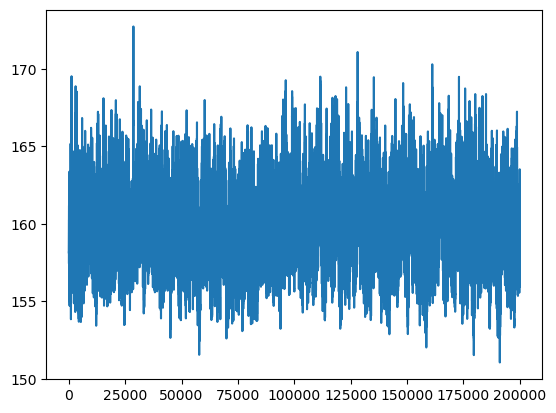

In [28]:
# plot the likelihood function for the MCMC samples
plt.plot(sample_Phi)
plt.show

In [29]:
# z = torch.randn(batch_size, latent_size)-1e1
# z = z.to(device)
# # print(z.shape)
# fake_images = G(z)
# # print(fake_images.shape)
# fake_images = fake_images.reshape(fake_images.size(0), 1, 28, 28)
# fake_images = fake_images.cpu().data

# fig, axes = plt.subplots(10, 10, figsize=(10, 10))
# for i, ax in enumerate(axes.flat):
#     ax.imshow(fake_images[i].reshape(28, 28), cmap='gray')
#     ax.axis('off')
# plt.tight_layout()
# plt.show()

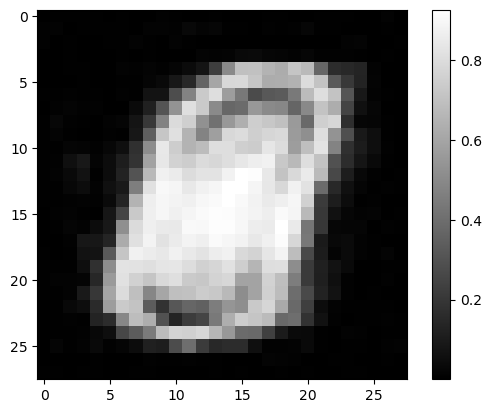

In [30]:
# View the standard deviation of MCMC samples in MNIST image space
sample_size = samples_MALA.shape[0]

images = samples_MALA.reshape(sample_size,latent_size).to(device)
sample_G = G(images)
sample_G = sample_G.reshape(sample_size,28,28).cpu().detach().numpy()

sample_G_std =  np.std(sample_G, axis=0)
plot_image(sample_G_std)

In [31]:
ACF_data = samples_MALA.reshape(sample_size,latent_size).cpu().detach().numpy()

KeyboardInterrupt: 

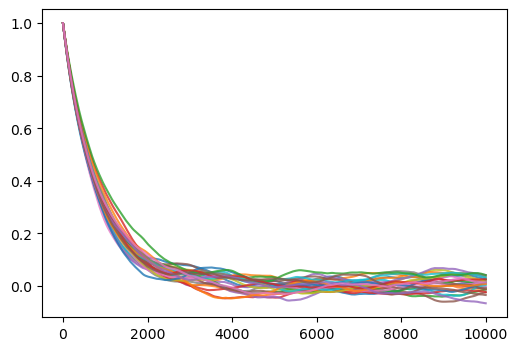

In [32]:
# plot Autocorelation function 
def autocorr_1d(x, max_lag=None):
    """Compute autocorrelation for a 1D array up to max_lag."""
    x = np.asarray(x)
    x = x - np.mean(x)
    result = np.correlate(x, x, mode='full')
    result = result[result.size // 2:]  
    result /= result[0]  
    if max_lag:
        return result[:max_lag]
    return result

data = ACF_data
max_lag = 10000  
plt.figure(figsize=(6, 4))
acf_list = []
for i in range(data.shape[1]):  
    # print(i)
    acf = autocorr_1d(data[:, i], max_lag=max_lag)
    acf_list.append(acf)
    plt.plot(range(max_lag), acf, alpha=0.8)

plt.grid(False)
plt.show()

In [ ]:
N_eff_list = np.zeros(data.shape[1])
for i in range(data.shape[1]):
    N = data.shape[0]
    rho_t = np.sum(acf_list[i])
    N_eff = N/(1+(2*rho_t))
    N_eff_list[i]=N_eff

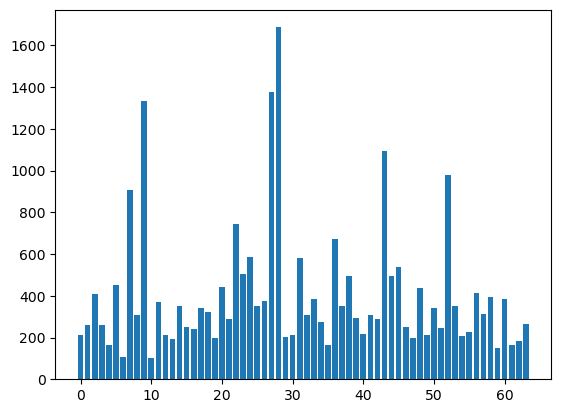

In [ ]:
# Plot Effective Sample Size
plt.bar(range(len(N_eff_list)),N_eff_list)
plt.show()